#### Multi-Label Classification

In [20]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

from copy import deepcopy  # 모델 파리미터 값 깊은 복사 (베스트 모델 저장용)

In [21]:
train_rowdata = datasets.MNIST(root='./dataset', train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.MNIST(root='./dataset', train=False, download=True, transform=transforms.ToTensor())

print(len(train_rowdata), len(test_dataset)) # 60000, 10000

60000 10000


Validation dataset 분리

In [22]:
VALIDATION_LATE = 0.2
train_idx, val_idx, _, _ = train_test_split(range(len(train_rowdata)), # X 인덱스 번호
                                      train_rowdata.targets, # y 레이블
                                      test_size=VALIDATION_LATE, # 분리 비율
                                      stratify=train_rowdata.targets # 균등 분포
                                      )

torch.utils.data.SubSet 으로 Validation dataset 생성

In [23]:
train_dataset = Subset(train_rowdata, train_idx) # Subset(원본데이터, 인덱스리스트)
val_dataset = Subset(train_rowdata, val_idx) # Subset(원본데이터, 인덱스리스트)

In [24]:
print(len(train_dataset), len(val_dataset), len(test_dataset)) # 48000, 12000

48000 12000 10000


**Mini batch 생성**

In [25]:
minibatch_size = 128

train_batches = DataLoader(train_dataset, batch_size=minibatch_size, shuffle=True)
val_batches = DataLoader(val_dataset, batch_size=minibatch_size, shuffle=True)
test_batches = DataLoader(test_dataset, batch_size=minibatch_size, shuffle=False)

torch.Size([128, 1, 28, 28]) torch.Size([128])


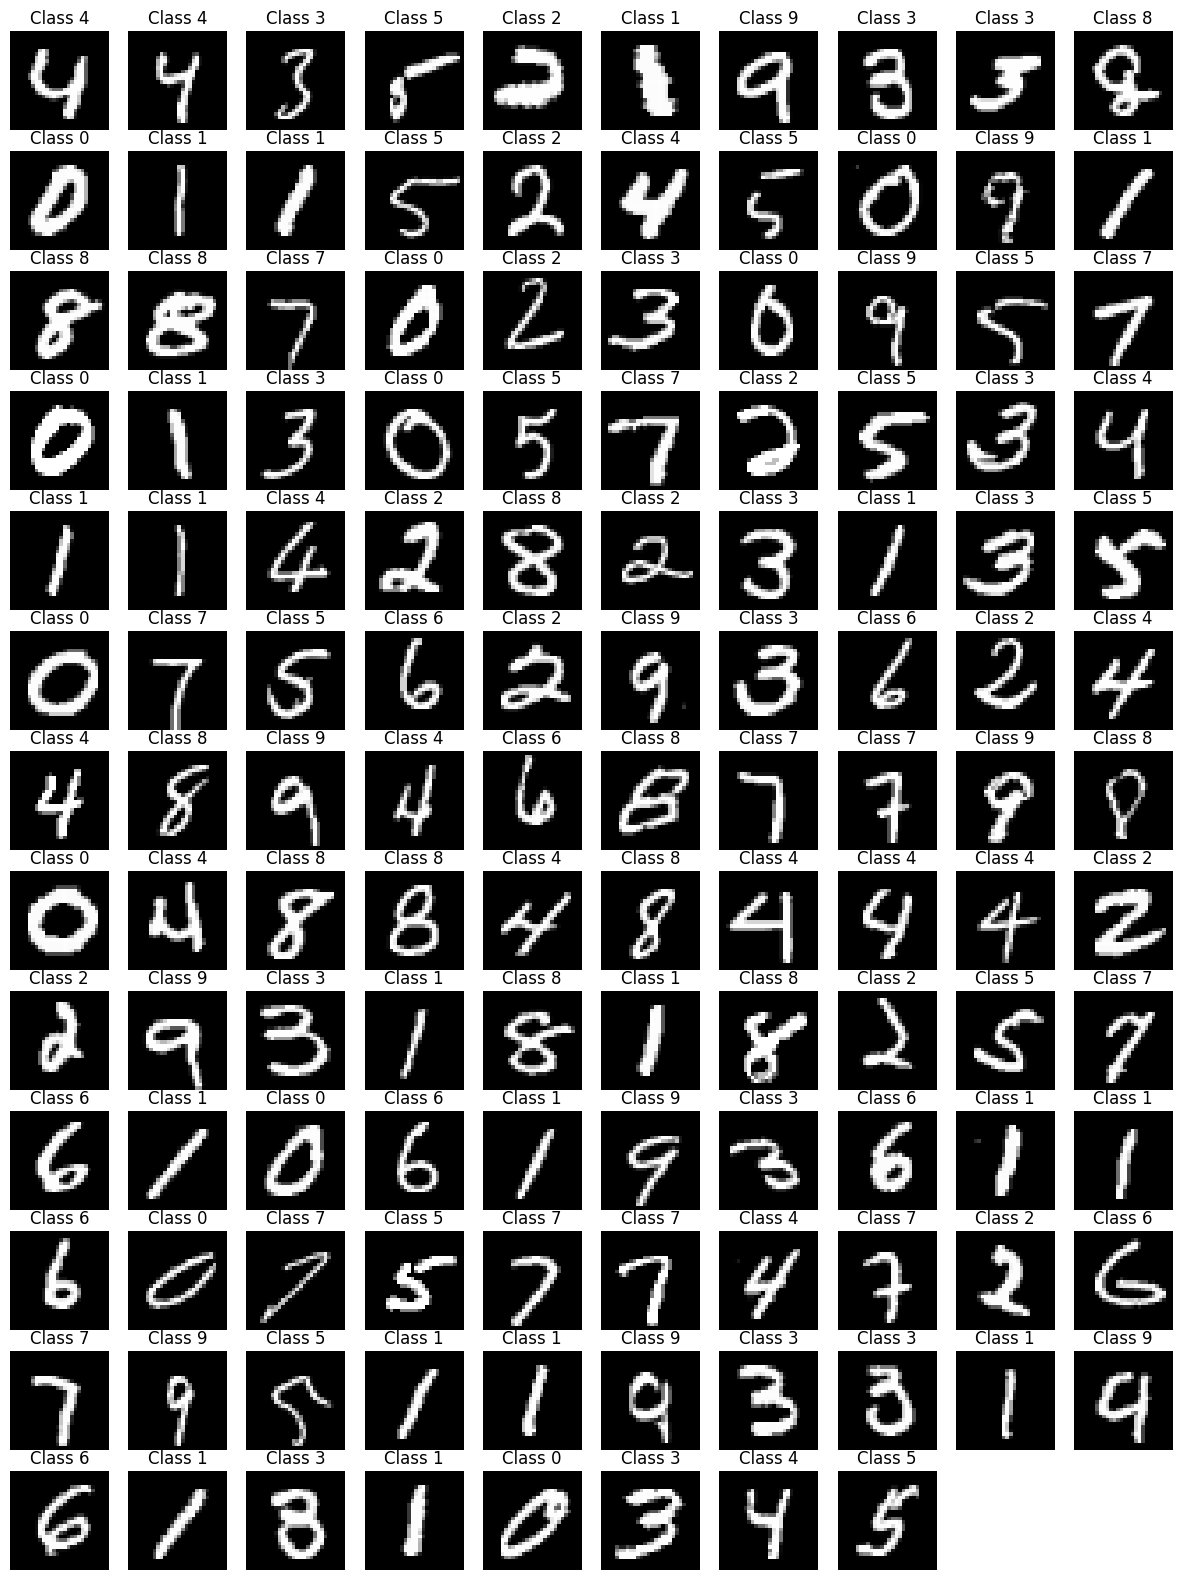

In [35]:
plt.figure(figsize=(15, 20))

X_train, y_train = next(iter(train_batches)) # 미니배치 1개 추출
print(X_train.shape, y_train.shape) # torch.Size([128, 1, 28, 28]) torch.Size([128])
for i in range(len(X_train)):
    plt.subplot(13, 10, i + 1)
    plt.imshow(X_train[i, :, :, :].squeeze(), cmap='gray') # (1, 28, 28) -> (28, 28)
    plt.title(f"Class {y_train[i].item()}")
    plt.axis('off') # x축, y축에 대한 옵션 설정, 축과 라벨을 표시하지 않음
plt.show()


#### BatchNorm

- nn.BatchNorm1d(C : 텐서 형태가 (N, C) 또는 (N, C, L) 인 경우 적용) : 2차원, 3차원
    - N 은 미니배치 사이즈 , C는 feature의 수, L 은 데이터 길이
 
- nn.BatchNorm2d(C : 텐서 형태가 (N, C, H, W) 경우 적용) : 4차원
    - N 은 미니배치 사이즈 , C는 feature의 수, H 와 W 는 height 와 width 를 의미함


In [37]:
class Layer(nn.Module):
    def __init__(self, input_size, output_size, batch_norm=True, dropout=0.5):
        self.input_size = input_size
        self.output_size = output_size
        self.batch_norm = batch_norm
        self.dropout = dropout
        super().__init__()
        
        self.layer = nn.Sequential(
            nn.Linear(input_size, output_size),
            nn.LeakyReLU(), # LeakyReLU 기본값은 0.01
            self.apply_regularization()
        )

    def apply_regularization(self):
        if self.batch_norm:
            return nn.BatchNorm1d(self.output_size) # 입력 사이즈를 넣어줘야 함 (입력이 그 앞단의 Linear Layer의 출력 사이즈가 됨)
        else :
            return nn.Dropout(self.dropout)

    def forward(self, x):
        return self.layer(x)

#### 별도 Layer 클래스 기반, 모델 정의
- 해당 모델도 별도 클래스로 정의하기로 함
- 마지막에는 Log softmax 값을 계산하기 위해, Linear 레이어를 추가해줘야 함

In [39]:
class DNNModel(nn.Module):
    def __init__(self, input_dim, output_dim, batch_norm=True, dropout=0.5):
        super().__init__()
        
        self.layers = nn.Sequential(
            Layer(input_dim, 256, batch_norm, dropout),
            Layer(256, 256, batch_norm, dropout),
            Layer(256, 128, batch_norm, dropout),
            nn.Linear(128, output_dim), # 마지막에는 Log softmax 값을 계산하기 위해, Linear 레이어를 추가해줘야 함
            nn.LogSoftmax(dim=-1) # dim : 소프트맥스를 적용할 차원 (마지막 차원 -1, 0, 1, 2, ...)
        )
    def forward(self, x):
        return self.layers(x)

**input, output, model 설정**

- model 출력시 각 layer 를 간결히 확인할 수 있음

In [56]:
input_dim = 28 * 28 # 784
output_dim = 10 # 0~9
# model = DNNModel(input_dim, output_dim, batch_norm=True, dropout=0.5)
model = DNNModel(input_dim, output_dim, batch_norm=False, dropout=0.2)

print(model) # model 출력시 각 layer 를 간결히 확인할 수 있음

DNNModel(
  (layers): Sequential(
    (0): Layer(
      (layer): Sequential(
        (0): Linear(in_features=784, out_features=256, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): Dropout(p=0.2, inplace=False)
      )
    )
    (1): Layer(
      (layer): Sequential(
        (0): Linear(in_features=256, out_features=256, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): Dropout(p=0.2, inplace=False)
      )
    )
    (2): Layer(
      (layer): Sequential(
        (0): Linear(in_features=256, out_features=128, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): Dropout(p=0.2, inplace=False)
      )
    )
    (3): Linear(in_features=128, out_features=10, bias=True)
    (4): LogSoftmax(dim=-1)
  )
)


**loss function, optimizer 설정**

In [57]:
loss_func = nn.NLLLoss() # 음의 로그 우도 손실 함수
optimizer = torch.optim.Adam(model.parameters()) # Adam 최적화

In [58]:
def train_model(model: nn.Module, early_stop: int, n_epochs:int, process_interval:int):
    
    train_losses, valid_losses, lowest_loss = list(), list(), np.inf # 리스트, 리스트, 무한대
    
    for epoch in range(n_epochs):
        
        train_loss, valid_loss = 0, 0 # 각각의 학습 데이터, 검증 데이터 손실 초기화
        # === Train ===
        model.train() # 모델을 학습 모드로 설정
        for x_minibatch, y_mini_batch in train_batches:
            y_mini_batch_pred = model(x_minibatch.view(x_minibatch.size(0), -1))
            loss = loss_func(y_mini_batch_pred, y_mini_batch)
            
            optimizer.zero_grad() # 기울기 초기화
            loss.backward() # 역전파
            optimizer.step() # 가중치 갱신
            
            train_loss += loss.item()
        
        train_loss /= len(train_batches) # 미니배치 개수로 나누어 평균 손실 계산
        train_losses.append(train_loss) # 리스트에 추가
        
        # === Valid ===
        model.eval() # 모델을 평가 모드로 설정
        with torch.no_grad(): # 평가시에는 기울기 계산을 하지 않음
            for x_minibatch, y_mini_batch in val_batches:
                y_mini_batch_pred = model(x_minibatch.view(x_minibatch.size(0), -1))
                valid_loss += loss_func(y_mini_batch_pred, y_mini_batch).item()
                
        valid_loss /= len(val_batches) # 미니배치 개수로 나누어 평균 손실 계산
        valid_losses.append(valid_loss) # 리스트에 추가
        
        if valid_losses[-1] < lowest_loss: # 가장 낮은 검증 손실 값 갱신
            lowest_loss = valid_losses[-1]
            lowest_epoch = epoch
            best_model = deepcopy(model.state_dict()) # 가장 낮은 검증 손실 값을 가진 모델 파라미터 저장

        else: 
            if (early_stop > 0) and (epoch - lowest_epoch >= early_stop): # early stop
                print(f"Early stopping at epoch {epoch+1}")
                break
        
        if (epoch % process_interval) == 0: # 지정한 간격마다 출력
            print(train_losses[-1], valid_losses[-1], lowest_loss, lowest_epoch, epoch)
    
    model.load_state_dict(best_model) # 가장 낮은 검증 손실 값을 가진 모델 파라미터로 복원
    return model, lowest_loss, train_losses, valid_losses


**훈련 실행**

In [59]:
nb_epochs = 30
process_interval = 3
early_stop = 10 # 10회 연속 검증 손실 값이 감소하지 않으면 조기 종료

model, lowest_loss, train_losses, valid_losses = train_model(model, early_stop, nb_epochs, process_interval)

0.4278494860132535 0.15636000778288284 0.15636000778288284 0 0
0.09102885795632998 0.09060630804680764 0.09060630804680764 3 3
0.056945163269837694 0.07225056915008958 0.07225056915008958 6 6
0.04142142838736375 0.07427856673367639 0.0721780701560226 7 9
0.03474908125338455 0.08190098033346077 0.0721780701560226 7 12
0.028141265340149404 0.07426012073088675 0.0721780701560226 7 15
0.024886071271806334 0.08021274553995797 0.07145605163098848 16 18
0.021109290520039698 0.07067440599859494 0.07067440599859494 21 21
0.01858542683534324 0.08104250214726447 0.07067440599859494 21 24
0.01910689909228434 0.08724860392233476 0.07067440599859494 21 27


In [60]:
test_loss = 0
correct = 0
wrong_samples, wrong_preds, actual_preds = list(), list(), list()

model.eval() # 모델을 평가 모드로 설정
with torch.no_grad(): # 평가시에는 기울기 계산을 하지 않음
    for x_minibatch, y_mini_batch in test_batches:
        y_test_pred = model(x_minibatch.view(x_minibatch.size(0), -1))
        test_loss += loss_func(y_test_pred, y_mini_batch).item()
        pred = torch.argmax(y_test_pred, dim=1) # 가장 높은 값을 가진 인덱스 추출
        correct += pred.eq(y_mini_batch).sum().item() # 예측값과 실제값이 같은 개수 합산
        
        wrong_idx = pred.ne(y_mini_batch).nonzero()[:, 0].numpy().tolist() # 예측값과 실제값이 다른 인덱스 추출
        for idx in wrong_idx:
            wrong_samples.append(x_minibatch[idx, :, :, :].squeeze()) # (1, 28, 28) -> (28, 28)
            wrong_preds.append(pred[idx].item())
            actual_preds.append(y_mini_batch[idx].item())
            
test_loss /= len(test_batches)
print('Average loss : {:.4f}'.format(test_loss))
print('Test accuracy : {:.2f}% ({}/{})'.format(100. * correct / len(test_dataset), correct, len(test_dataset)))


Average loss : 0.0799
Test accuracy : 98.16% (9816/10000)


**incorrect data만 확인해보기**

In [61]:
print(len(wrong_samples), len(wrong_preds), len(actual_preds))

184 184 184


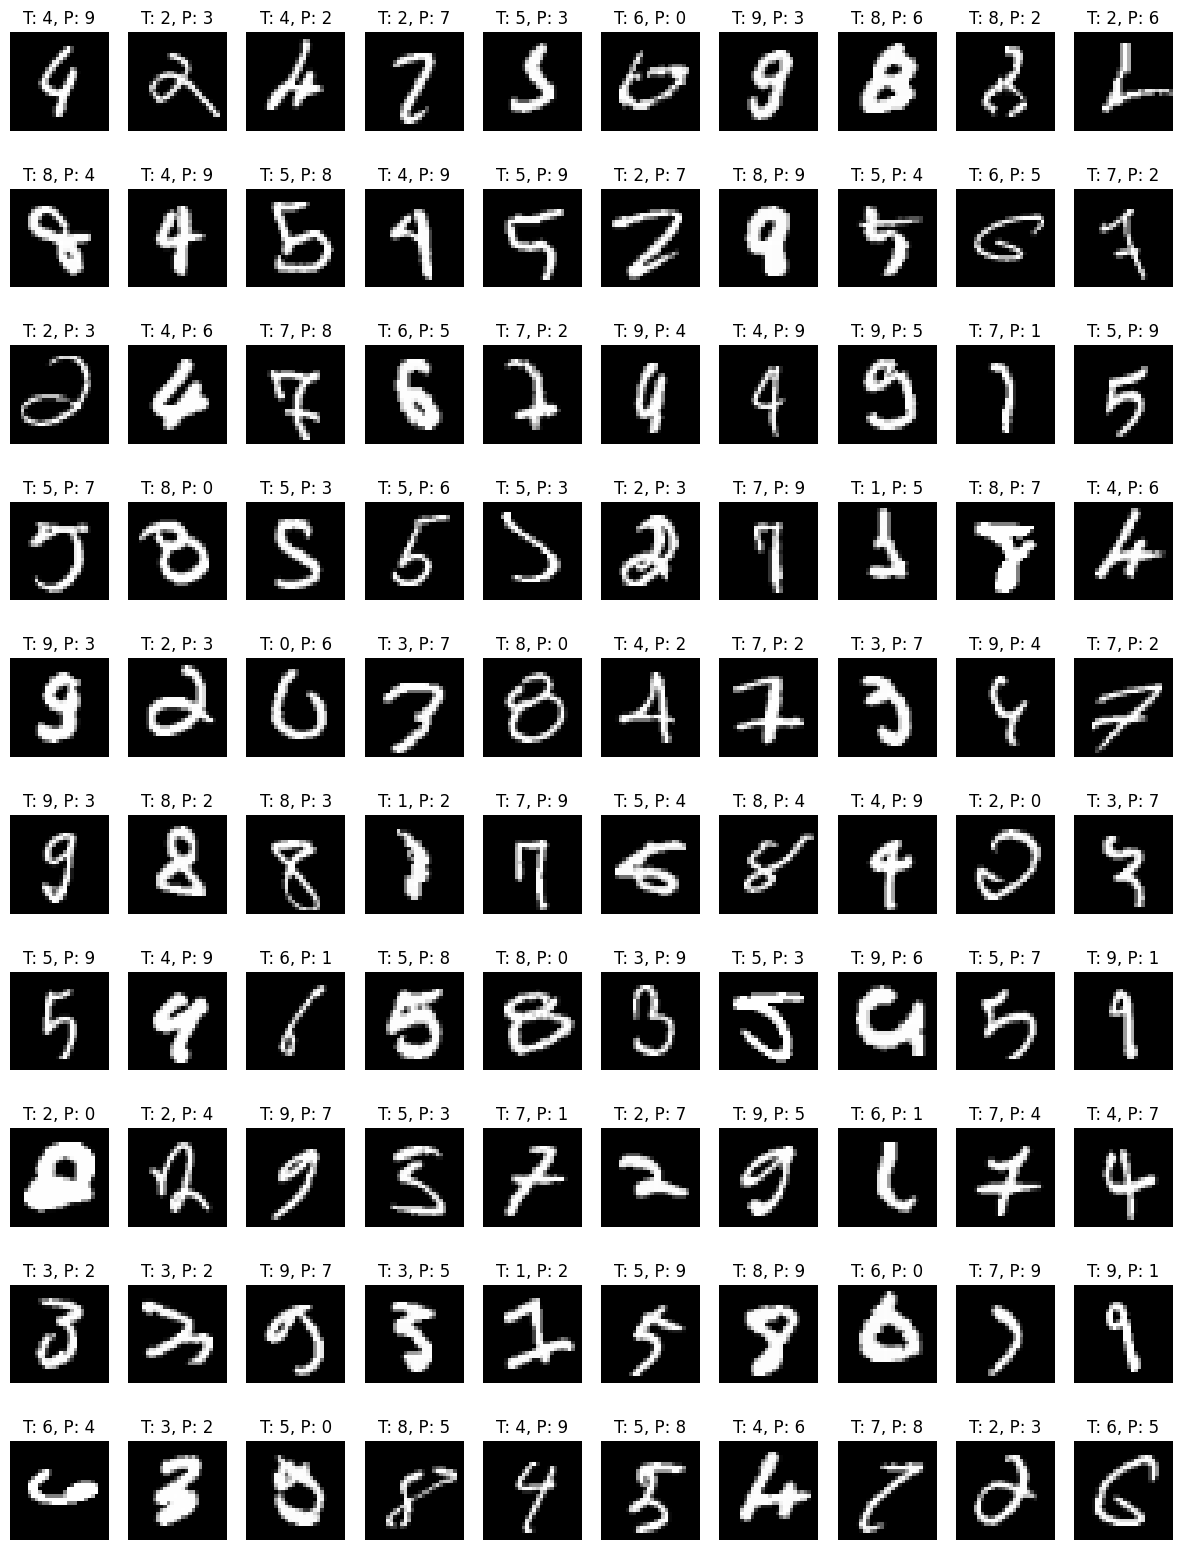

In [62]:
plt.figure(figsize=(15, 20))

for i in range(100):
    plt.subplot(10, 10, i + 1)
    plt.imshow(wrong_samples[i], cmap='gray') # (1, 28, 28) -> (28, 28)
    plt.title(f"T: {actual_preds[i]}, P: {wrong_preds[i]}")
    plt.axis('off') # x축, y축에 대한 옵션 설정, 축과 라벨을 표시하지 않음